In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.fft import fft, ifft, fftfreq
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In this notebook we implement a ResNet solver for the 1-dimensional Kuramoto--Sivashinsky equation:
$$\frac{\partial u}{\partial t} + \frac{\partial^2 u}{\partial x^2} + \frac{\partial^4 u}{\partial x^4} + \frac{1}{2}\frac{\partial (u^2)}{\partial x} = 0.$$
Using the Fourier transform we have
$$\frac{\partial \hat u}{\partial t} = L\hat u + N\hat u,$$
where $L$ and $N$ are the linear and nonlinear part of the equation.  We implement a differentiable solver using the ETDRK2 method along with using the $2/3$ dealiasing rule before nonlinear operations.  A reference for the ETDRK2 can be found in [this paper](https://www.sciencedirect.com/science/article/abs/pii/S0021999102969950).  A good summary of aliasing errors and dealiasing using the $2/3$ rule can be found [here](https://qiauil.github.io/torchfsm/theory/#discretization-and-aliasing-error).

In [3]:
class KS_solver:
    def __init__(self, X, N, dt, precision='double'):
        self.X = X
        self.dt = dt
        if precision == 'double':
            self.dtype = torch.float64
        if precision == 'single':
            self.dtype = torch.float32
        freq = fftfreq(N, X/N, dtype=self.dtype)
        self.mask = torch.where(torch.abs(freq * X) > N/3, torch.zeros_like(freq), torch.ones_like(freq))
        self.mask = self.mask.to(device)
        self.wavenum = 2 * torch.pi * freq
        self.wavenum = self.wavenum.to(device)
        L = self.wavenum ** 2 - self.wavenum ** 4
        self.const1 = torch.exp(L * dt)
        self.const2 = torch.nan_to_num((torch.exp(L * dt) - 1) / L, nan=dt, posinf=dt, neginf=dt)
        self.const3 = torch.nan_to_num((torch.exp(L * dt) - 1 - L * dt) / ((L ** 2) * dt), nan=dt / 2, posinf=dt / 2, neginf=dt / 2)

    def __call__(self, u, num_steps=1):
        if u.dtype != self.dtype:
            u = u.to(self.dtype)
        u_hat = fft(u)
        if num_steps > 1:
            res_f = [u_hat]
            for _ in range(num_steps):
                N_u_hat = self.N(u_hat)
                a = u_hat * self.const1 + N_u_hat * self.const2
                u_hat = a + (self.N(a) - N_u_hat) * self.const3
                res_f.append(u_hat)
            return ifft(torch.stack(res_f)).real
        elif num_steps == 1:
            N_u_hat = self.N(u_hat)
            a = u_hat * self.const1 + N_u_hat * self.const2
            u_hat = a + (self.N(a) - N_u_hat) * self.const3
            return ifft(u_hat).real
        else:
            raise ValueError("num_steps must be a positive integer.")

    def N(self, u_hat):
        dealiased_u_hat = u_hat * self.mask
        dealiased_u = ifft(dealiased_u_hat).real
        return -1j * self.wavenum * fft(dealiased_u ** 2) / 2


Here we have a simulation generator, which generate solutions to the 1D KS equation with initial conditions
$$u_0 = \cos(3 \pi x/ X) \pm 0.1\cos(2\pi x/X)(1 - \alpha\sin(2\pi x / X)),$$
where the $\pm$ is chosen uniformly and $\alpha$ is sampled uniformly in $[-8,8]$.

In [4]:
class DataGenerator:
    def __init__(self, X, N, dt, num_samples, num_simulations):
        solver = KS_solver(X, N, dt)
        xx = torch.linspace(0, X, N, dtype=torch.float64)
        simulations = []
        for _ in range(num_simulations):
            alpha = -16 * torch.rand(1, dtype=torch.float64) + 8
            if torch.rand(1).item() > 0.5:
                factor = 0.1
            else:
                factor = -0.1
            u_0 = torch.cos(3 * torch.pi * xx / X) + factor * torch.cos(2 * torch.pi * xx / X) * (1 - alpha * torch.sin(2 * torch.pi * xx / X))
            u_0 = u_0.to(device)
            simulations.append(solver(u_0, num_steps=num_samples))
        self.data = torch.stack(simulations)


Our ResNet solver with six residual blocks, where we use 1d convolutions as our layers.  The reference for ResNet and residual blocks can be found [here](https://arxiv.org/abs/1512.03385).

In [5]:
class residual_block(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, hidden_channels, 3, padding=1, padding_mode='circular')
        self.conv2 = nn.Conv1d(hidden_channels, out_channels, 3, padding=1, padding_mode='circular')

    def forward(self, x):
        y = F.relu(self.conv1(x))
        y = self.conv2(y)
        return F.relu(x + y)

class NN_solver(nn.Module):
    def __init__(self):
        super().__init__()
        self.block1 = residual_block(1, 16, 32)
        self.block2 = residual_block(32, 32, 32)
        self.block3 = residual_block(32, 32, 32)
        self.block4 = residual_block(32, 32, 32)
        self.block5 = residual_block(32, 32, 32)
        self.block6 = residual_block(32, 32, 32)
        self.conv = nn.Conv1d(32, 1, 1)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.block6(x)
        x = self.conv(x)
        return x


We generate 6 simulations with 8000 samples each, with $X = 60$ discretized into $N = 100$ grid cells, with timestep $dt = 0.5$.

In [7]:
X = 60
N = 100
dt = 0.5
num_steps = 8000
num_samples = 6

In [10]:
dataset = DataGenerator(X, N, dt, num_steps, num_samples)

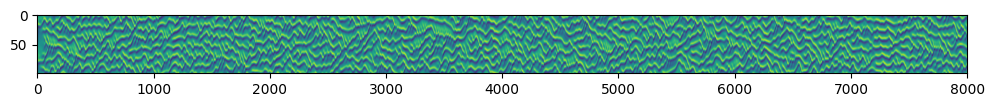

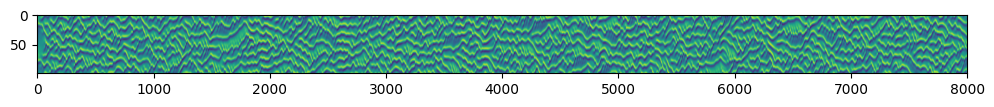

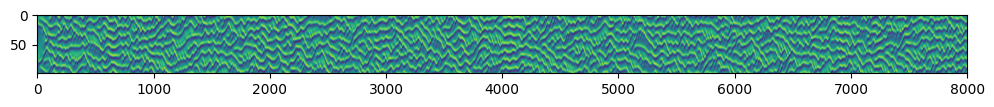

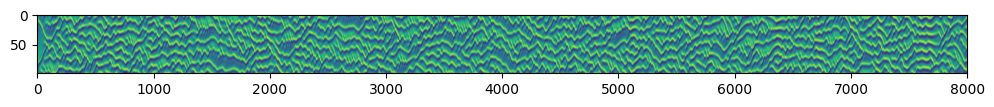

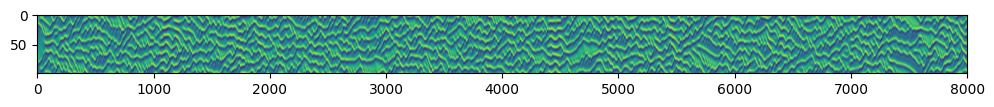

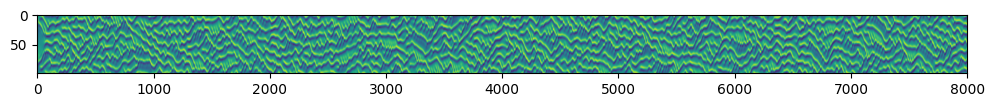

In [11]:
for data in dataset.data:
    plt.figure(figsize=(12,6))
    plt.imshow(data.t().cpu(), aspect='5')
    plt.show()

The first 5 simulations are used for training, and 300 consecutive samples from the last simulation are used for testing a long rollout case.

In [35]:
batch_size = 64

train_dataset = dataset.data[:num_samples - 1]
test_dataset = dataset.data[num_samples - 1][1200:1501]

supervised_train = train_dataset[:, :-1, :].reshape(-1, 1, N), train_dataset[:, 1:, :].reshape(-1, 1, N)

s = 3
unrolling_train = []
unrolling_val = []
for i in range(s + 1):
    unrolling_train.append(train_dataset[:, i:num_steps + 1 - s + i, :].reshape(-1, 1, N))

dp_loader = DataLoader(train_dataset.reshape(-1, 1, N), batch_size=batch_size, shuffle=True)
supervised_loader = DataLoader(TensorDataset(*supervised_train), batch_size=batch_size, shuffle=True)
unrolling_loader = DataLoader(TensorDataset(*unrolling_train), batch_size=batch_size, shuffle=True)

We implement three training methods.  The first one is supervised training with the loss function being the $L^2$ loss:
$$\mathcal L = \|NN(u_n) - u_{n+1}\|_2.$$
The second one features step unrolling with the loss function being
$$\mathcal L = \sum_{k=1}^s \|NN^k(u_n) - u_{n+k}\|_2,$$
where $s = 3$.
The third one is unsupervised training with the solver, with the loss function being
$$\mathcal L = \sum_{k=1}^s \frac{\|NN^k(u) - \mathcal P(NN^{k-1}(u))\|_2}{\|NN^k(u)\|_2},$$
where $NN^0$ is the identity map and $\mathcal P$ is the solver.

To test our models, we run 300 consecutive predictions using our models.  The predictions and the ground truth are shown as well as the absolute error on each grid cell.  We also plot the relative $L^2$ loss over prediction time.

In [56]:
solver = KS_solver(X, N, dt, precision='single')

def train(model, train_loader, train_method, num_epoch):

    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 10, gamma=0.1)
    tqdm_epoch = tqdm(range(num_epoch))
    avg_loss = []

    for epoch in tqdm_epoch:

        model.train()

        total_loss = 0
        total_num = 0

        for data in train_loader:

            optimizer.zero_grad()

            if train_method == "supervised":
                for i in range(len(data)):
                    data[i] = data[i].to(device)
                loss = torch.mean(torch.norm(model(data[0].float()) - data[1], dim=-1))
            if train_method == "unrolling":
                for i in range(len(data)):
                    data[i] = data[i].to(device)
                u_s = model(data[0].float())
                loss = torch.mean(torch.norm(u_s - data[1], dim=-1))
                for i in range(2, s + 1):
                    u_s = model(u_s)
                    loss += torch.mean(torch.norm(u_s - data[i], dim=-1))
            if train_method == "dp":
                data = data.to(device)
                u_s = model(data.float())
                loss = torch.mean(torch.norm(u_s - solver(data), dim=-1) / torch.norm(u_s, dim=-1))
                for _ in range(2, s + 1):
                    data = u_s
                    u_s = model(u_s)
                    loss += torch.mean(torch.norm(u_s - solver(data), dim=-1) / torch.norm(u_s, dim=-1))
            loss.backward()

            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

            optimizer.step()

            total_loss += loss.detach().item() * batch_size
            total_num += batch_size

        avg_loss.append(total_loss / total_num)
        tqdm_epoch.set_description(f'Average loss: {total_loss / total_num}')
        scheduler.step()

    print("Training complete")

def test(model, training_method, rollout_steps):
    model = model.to(device)
    u_s = test_dataset[0][None, :]
    simulation = []
    model.eval()
    with torch.no_grad():
        for _ in range(rollout_steps):
            u_s = model(u_s.float())
            simulation.append(u_s)
        simulation = torch.cat(simulation)
        ground_truth = test_dataset[1:rollout_steps + 1]

        fig = plt.figure(figsize=(12,6))
        ax1 = fig.add_subplot(2,2,1)
        ax2 = fig.add_subplot(2,2,2)
        ax3 = fig.add_subplot(2,2,3)
        ax4 = fig.add_subplot(2,2,4)
        ax1.imshow(simulation.t().cpu(), cmap='jet',
                   vmin=min(simulation.cpu().min(), ground_truth.cpu().min()),
                   vmax=max(simulation.cpu().max(), ground_truth.cpu().max()))
        ax1.set_title("Simulation by NN")
        ax2.imshow(ground_truth.t().cpu(), cmap='jet',
                   vmin=min(simulation.cpu().min(), ground_truth.cpu().min()),
                   vmax=max(simulation.cpu().max(), ground_truth.cpu().max()))
        ax2.set_title("Ground truth")
        err = ax3.imshow(torch.abs(simulation - ground_truth).t().cpu(), cmap='jet')
        fig.colorbar(err, ax=ax3)
        ax3.set_title("Absolute error")
        ax4.plot(range(1, rollout_steps + 1), torch.norm(simulation - ground_truth, dim=-1).cpu() / torch.norm(ground_truth, dim=-1).cpu())
        ax4.set_title("Relative L2 loss over prediction-time")
        fig.suptitle(f"{training_method} model")
        plt.show()


In [47]:
supervised_model = NN_solver()
train(supervised_model, supervised_loader, "supervised", 40)

Average loss: 0.03531176674853298: 100%|██████████| 40/40 [04:20<00:00,  6.51s/it]

Training complete


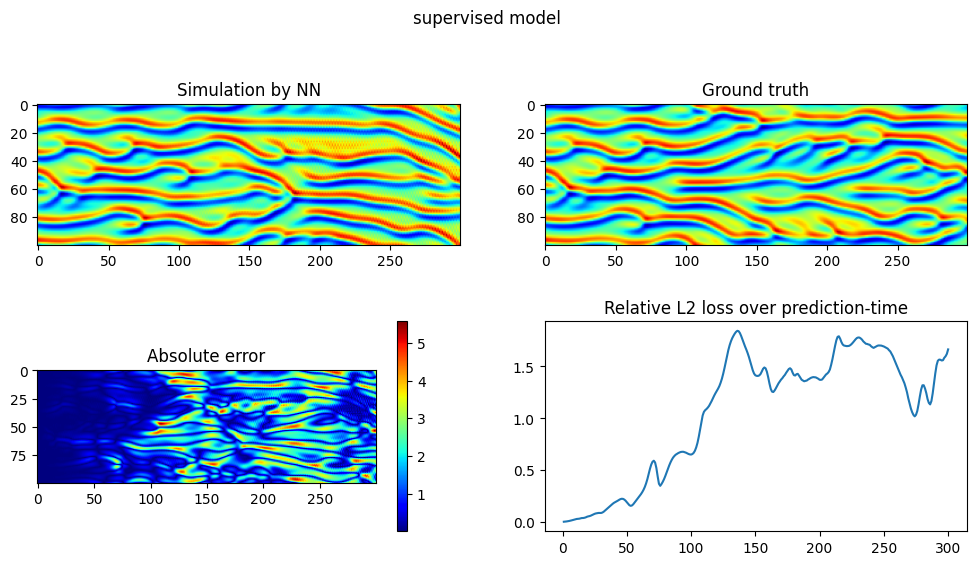

In [57]:
test(supervised_model, "supervised", 300)

In [60]:
unrolling_model = NN_solver()
train(unrolling_model, unrolling_loader, "unrolling", 40)

Average loss: 0.18490554834911285: 100%|██████████| 40/40 [11:52<00:00, 17.82s/it]

Training complete


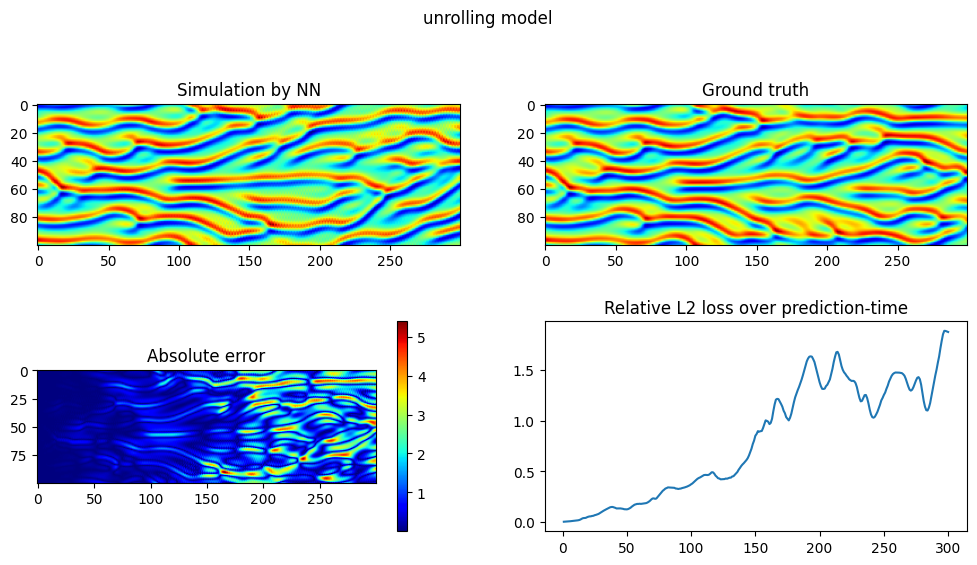

In [61]:
test(unrolling_model, "unrolling", 300)

In [76]:
dp_model = NN_solver()
train(dp_model, dp_loader, "dp", 40)

Average loss: 0.007009888975360333: 100%|██████████| 40/40 [13:11<00:00, 19.78s/it]

Training complete


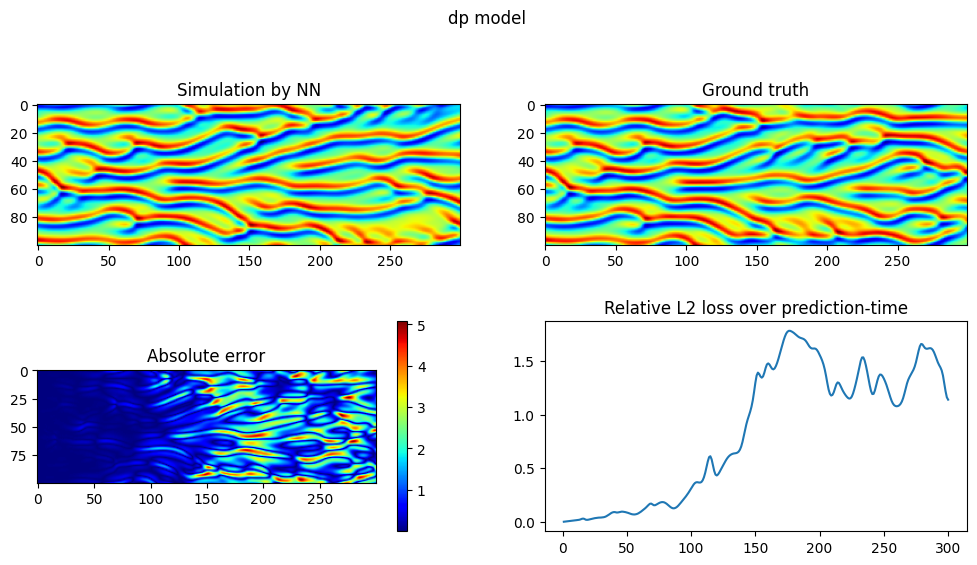

In [77]:
test(dp_model, "dp", 300)

We now plot the relative $L^2$ losses over prediction time for all models in the same graph.  It can be seen that step unrolling whether in the supervised or unsupervised form enhances stability and just a small step $s = 3$ already helps improving long rollouts during testing.

In [65]:
def plot_test_loss(rollout_steps):
    ground_truth = test_dataset[1:rollout_steps + 1]
    name_list = ["supervised", "unrolling", "differentiable physics"]
    for i, model in enumerate([supervised_model, unrolling_model, dp_model]):
        model = model.to(device)
        u_s = test_dataset[0][None, :]
        simulation = []
        model.eval()
        with torch.no_grad():
            for _ in range(rollout_steps):
                u_s = model(u_s.float())
                simulation.append(u_s)
            simulation = torch.cat(simulation)
        plt.plot(range(1, rollout_steps + 1), torch.norm(simulation - ground_truth, dim=-1).cpu() / torch.norm(ground_truth, dim=-1).cpu(), label=name_list[i])
    plt.title("Relative L2 loss over prediction-time")
    plt.legend()
    plt.show()


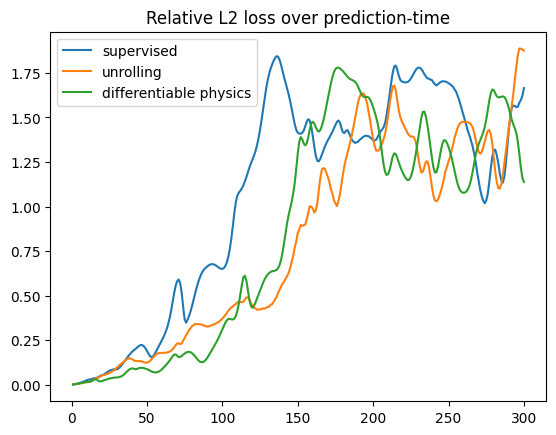

In [78]:
plot_test_loss(300)